In [ ]:
# Importing all necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import io
import matplotlib.pyplot as plt
import plotly.express as px
import geopandas as gpd
import plotly.graph_objects as go
%matplotlib inline
plt.style.use('seaborn-v0_8')
# Style to be used for visualization

In [ ]:
population = pd.read_csv('population_per_county_cleaned.csv')
# Reading our first cleaned CSV file

population.head()
# Display the first few rows of the DataFrame


,County,Population
0,Carlow,61968
1,Cavan,81704
2,Clare,127938
3,Cork,584156
4,Donegal,167084


In [ ]:
nurses = pd.read_csv('registered_nurses_per_county_cleaned.csv')
nurses = nurses.rename(columns={'Total': 'Total Nurses'})
# Renaming columns for clarity before merging later

nurses.head()

,County,Total Nurses
0,Donegal,2424
1,Cavan,1189
2,Leitrim,259
3,Sligo,1862
4,Mayo,1927


In [ ]:
import pandas as pd
hse_df = pd.read_csv('hse_hospitals_cleaned.csv', encoding = 'latin1')
# Using latin1 encoding to handle special characters that may cause a UnicodeDecodeError

hse_df.head()

,OBJECTID,category,subcategory,name,address1,address2,address3,address4,beds,FullAddress,Eircode,POINT_X,POINT_Y,County
0,94,Hospital,Mixed Use,Saint Colman's Hospital,Ballygannon,Rathdrum,Co. Wicklow,NaN,92,Saint Colman's Hospital Ballygannon Rathdrum C...,A67 AK06,-6.239776,52.933818,Wicklow
1,101,Hospital,Community,Saint Mary's Hospital - Castleblayney,Bree,Castleblayney,Co. Monaghan,NaN,70,Saint Mary's Hospital - Castleblayney Bree Cas...,A75 TD61,-6.744803,54.120058,Monaghan
2,82,Hospital,General/Acute,Our Lady of Lourdes Hospital Drogheda,Drogheda,Co. Louth,NaN,NaN,340,Our Lady of Lourdes Hospital Drogheda Drogheda...,A92 VW28,-6.354947,53.722735,Louth
3,37,Hospital,Continuing Care Service,Drogheda,Saint Mary's Hospital,Dublin Road,Drogheda,Co. Louth,345,Drogheda Saint Mary's Hospital Dublin Road Dro...,A92 X862,-6.341016,53.711363,Louth
4,13,Hospital,Private General,Blackrock Clinic,Rock Road,Blackrock,Co. Dublin,NaN,232,Blackrock Clinic Rock Road Blackrock Co. Dublin,A94 E4X7,-6.188172,53.303468,Dublin


In [ ]:
hse_df.shape
# Checking DataFrame dimensions

(126, 14)

In [ ]:
hse_df.info()
# Check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   OBJECTID     126 non-null    int64  
 1   category     126 non-null    object 
 2   subcategory  126 non-null    object 
 3   name         126 non-null    object 
 4   address1     126 non-null    object 
 5   address2     124 non-null    object 
 6   address3     74 non-null     object 
 7   address4     11 non-null     object 
 8   beds         126 non-null    int64  
 9   FullAddress  126 non-null    object 
 10  Eircode      126 non-null    object 
 11  POINT_X      126 non-null    float64
 12  POINT_Y      126 non-null    float64
 13  County       126 non-null    object 
dtypes: float64(2), int64(2), object(10)
memory usage: 13.9+ KB


In [ ]:
hse_df.isnull().sum()
# Checking for null values in attributes to be used in analysis

,0
OBJECTID,0
category,0
subcategory,0
name,0
address1,0
address2,2
address3,52
address4,115
beds,0
FullAddress,0


In [ ]:
hse_df.columns
# Display all columns to help with dropping columns syntax

Index(['OBJECTID', 'category', 'subcategory', 'name', 'address1', 'address2',
       'address3', 'address4', 'beds', 'FullAddress', 'Eircode', 'POINT_X',
       'POINT_Y', 'County'],
      dtype='object')

In [ ]:
hse_df.drop(columns = ['OBJECTID', 'category', 'subcategory', 'address1', 'address2', 'address3', 'address4', 'FullAddress', 'Eircode'], axis=1, inplace=True)
# Retained 'name', 'POINT_X' and 'POINT_Y' for mapping later

hse_df = hse_df.rename(columns={'beds': 'Total Beds'})
# Renaming columns for clarity before merging later

hse_df.head(10)

,name,Total Beds,POINT_X,POINT_Y,County
0,Saint Colman's Hospital,92,-6.239776,52.933818,Wicklow
1,Saint Mary's Hospital - Castleblayney,70,-6.744803,54.120058,Monaghan
2,Our Lady of Lourdes Hospital Drogheda,340,-6.354947,53.722735,Louth
3,Drogheda,345,-6.341016,53.711363,Louth
4,Blackrock Clinic,232,-6.188172,53.303468,Dublin
5,National Rehab,129,-6.152577,53.275810,Dublin
6,St. Michael's Hospital,118,-6.138523,53.293802,Dublin
7,Our Lady's Hospital Navan,125,-6.697145,53.650301,Meath
8,Temple Street Children's University Hospital,227,-6.262158,53.357275,Dublin
9,Rotunda Hospital,198,-6.263159,53.352344,Dublin


In [ ]:
from shapely.geometry import Point

# Create a geometry column from POINT_X and POINT_Y
geometry = [Point(xy) for xy in zip(hse_df['POINT_X'], hse_df['POINT_Y'])]

# Create a GeoDataFrame
hospitals_gdf = gpd.GeoDataFrame(hse_df, geometry=geometry)

# Set the Coordinate Reference System (CRS). A common one for lat/lon is EPSG:4326
hospitals_gdf.crs = 'EPSG:4326'

# Saved directly to a SHP file for use in Data Vizualisation later
hospitals_gdf.to_file('hospital_locations.shp')
print("Hospital locations saved to 'hospital_locations.shp'")

Hospital locations saved to 'hospital_locations.shp'


In [ ]:
county_hospital_counts = hse_df.groupby('County').size().reset_index()
# After grouping by 'County', 'size' will count the number of hospitals in each county

county_hospital_counts.columns = ['County', 'Hospitals']
# Renaming columns

print("Total Hospitals per County:")
display(county_hospital_counts)

Total Hospitals per County:


,County,Hospitals
0,Carlow,1
1,Cavan,1
2,Clare,4
3,Cork,22
4,Donegal,10
5,Dublin,28
6,Galway,6
7,Kerry,7
8,Kildare,2
9,Kilkenny,4


In [ ]:
# Saved directly to a CSV file
county_hospital_counts.to_csv('hse_hospitals_extracted.csv', header = True)
print("Hospital counts per county saved to 'hse_hospitals_extracted.csv'")

Hospital counts per county saved to 'hse_hospitals_extracted.csv'


In [ ]:
total_beds_per_county = hse_df.groupby('County')['Total Beds'].sum().reset_index()
# Calculating the sum of the 'Total Beds' for each county and grouping by county

print("Total Beds per County:")
display(total_beds_per_county)

Total Beds per County:


,County,Total Beds
0,Carlow,115
1,Cavan,264
2,Clare,270
3,Cork,2514
4,Donegal,791
5,Dublin,7350
6,Galway,1116
7,Kerry,696
8,Kildare,358
9,Kilkenny,421


In [ ]:
# Saved directly to a CSV file
total_beds_per_county.to_csv('total_beds_extracted.csv', header = True)
print("Total beds per county saved to 'total _beds_extracted.csv'")

Total beds per county saved to 'total _beds_extracted.csv'


In [ ]:
import pandas as pd
ppr_df = pd.read_csv('ppr_2025_raw.csv', encoding = 'latin1')
# Encoding added as there was an error with the euro signs used in 'Price ()' column

ppr_df.head()

,Date of Sale (dd/mm/yyyy),Address,County,Eircode,Price,Not Full Market Price,VAT Exclusive,Description of Property,Property Size Description
0,02/01/2025,"11 DAVIS COURT, THOMAS DAVIS ST WEST, INCHICOR...",Dublin,D08WK61,239000.00,No,No,Second-Hand Dwelling house /Apartment,NaN
1,02/01/2025,"148 Forgelands, Old Forge Road, Enniscorthy",Wexford,NaN,281938.33,No,Yes,New Dwelling house /Apartment,NaN
2,02/01/2025,"17 STATION COURT PARK, COOLMINE, DUBLIN 15",Dublin,D15PF25,326000.00,No,No,Second-Hand Dwelling house /Apartment,NaN
3,02/01/2025,"17 THE AVENUE, WALSHESTOWN PARK, NEWBRIDGE",Kildare,W12FW73,205000.00,No,No,Second-Hand Dwelling house /Apartment,NaN
4,02/01/2025,"2 LOIAMORE LAWN, BANDUFF, CO CORK",Cork,T23V8Y0,230000.00,No,No,Second-Hand Dwelling house /Apartment,NaN


In [ ]:
ppr_df.shape

(61922, 9)

In [ ]:
ppr_df.info()
# Check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61922 entries, 0 to 61921
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date of Sale (dd/mm/yyyy)  61922 non-null  object 
 1   Address                    61922 non-null  object 
 2   County                     61922 non-null  object 
 3   Eircode                    45890 non-null  object 
 4   Price                      61922 non-null  float64
 5   Not Full Market Price      61922 non-null  object 
 6   VAT Exclusive              61922 non-null  object 
 7   Description of Property    61922 non-null  object 
 8   Property Size Description  0 non-null      float64
dtypes: float64(2), object(7)
memory usage: 4.3+ MB


In [ ]:
ppr_df.isnull().sum()
# There are no null values in County or Price columns so I don't need to .dropna

,0
Date of Sale (dd/mm/yyyy),0
Address,0
County,0
Eircode,16032
Price,0
Not Full Market Price,0
VAT Exclusive,0
Description of Property,0
Property Size Description,61922


In [ ]:
ppr_df.columns

Index(['Date of Sale (dd/mm/yyyy)', 'Address', 'County', 'Eircode', 'Price',
       'Not Full Market Price', 'VAT Exclusive', 'Description of Property',
       'Property Size Description'],
      dtype='object')

In [ ]:
ppr_df.drop(columns=['Date of Sale (dd/mm/yyyy)', 'Address', 'Eircode', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description'], axis=1, inplace=True)
# Removed: Date of Sale (dd/mm/yyyy)', 'Address', 'Eircode', 'Price ()', 'Not Full Market Price', 'VAT Exclusive', 'Description of Property', 'Property Size Description' because they aren't useful for my analysis

ppr_df.head(10)

,County,Price
0,Dublin,239000.00
1,Wexford,281938.33
2,Dublin,326000.00
3,Kildare,205000.00
4,Cork,230000.00
5,Dublin,1050000.00
6,Meath,338000.00
7,Wexford,227500.00
8,Cork,370000.00
9,Dublin,395000.00


In [ ]:
average_price_per_county = ppr_df.groupby('County')['Price'].mean()
# Group by average price by county, and change to integer for analysis

average_price_per_county.name = 'Average House Price'
# Rename to 'Average House Price'

average_price_per_county = average_price_per_county.round(2)
display(average_price_per_county)

,Average House Price
County,
Carlow,306912.66
Cavan,261812.36
Clare,322700.49
Cork,372287.46
Donegal,230972.89
Dublin,671736.04
Galway,385698.65
Kerry,346315.14
Kildare,426093.77


In [ ]:
# saved directly to a CSV file
average_price_per_county.to_csv('ppr_2025_extracted.csv', header = True)
print("Average price per county saved to 'ppr_2025_extracted.csv'")

Average price per county saved to 'ppr_2025_extracted.csv'


In [ ]:
rtb_df = pd.read_csv('rtb_average_monthly_rent_report_raw.csv', encoding = 'latin1')
rtb_df.head()

,ï»¿STATISTIC Label,Quarter,Number of Bedrooms,Property Type,Location,UNIT,VALUE
0,RTB Average Monthly Rent Report,2025Q1,All bedrooms,All property types,Carlow,Euro,1208.03
1,RTB Average Monthly Rent Report,2025Q1,All bedrooms,All property types,Carlow Town,Euro,1223.71
2,RTB Average Monthly Rent Report,2025Q1,All bedrooms,All property types,"Graiguecullen, Carlow",Euro,NaN
3,RTB Average Monthly Rent Report,2025Q1,All bedrooms,All property types,"Tullow, Carlow",Euro,1280.53
4,RTB Average Monthly Rent Report,2025Q1,All bedrooms,All property types,Cavan,Euro,1048.10


In [ ]:
rtb_df.shape

(56196, 7)

In [ ]:
rtb_df.info()
# Check data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56196 entries, 0 to 56195
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ï»¿STATISTIC Label  56196 non-null  object 
 1   Quarter             56196 non-null  object 
 2   Number of Bedrooms  56196 non-null  object 
 3   Property Type       56196 non-null  object 
 4   Location            56196 non-null  object 
 5   UNIT                56196 non-null  object 
 6   VALUE               8770 non-null   float64
dtypes: float64(1), object(6)
memory usage: 3.0+ MB


In [ ]:
rtb_df.isnull().sum()
# 47426 values in 'Value' column out of possible 56196 so I need to remove all NaN

,0
ï»¿STATISTIC Label,0
Quarter,0
Number of Bedrooms,0
Property Type,0
Location,0
UNIT,0
VALUE,47426


In [ ]:
rtb_df.describe()

,VALUE
count,8770.000000
mean,1541.856798
std,512.836001
min,479.590000
25%,1137.260000
50%,1443.135000
75%,1882.435000
max,5468.940000


In [ ]:
rtb_df.columns
# Checking column names before dropping below

Index(['ï»¿STATISTIC Label', 'Quarter', 'Number of Bedrooms', 'Property Type',
       'Location', 'UNIT', 'VALUE'],
      dtype='object')

In [ ]:
rtb_df.drop(columns=['ï»¿STATISTIC Label', 'Quarter', 'Number of Bedrooms', 'Property Type', 'UNIT'], axis=1, inplace=True)
# Removed: 'ï»¿STATISTIC Label', 'Quarter', 'Number of Bedrooms', 'Property Type', and 'UNIT' because they aren't useful for my analysis.

rtb_df.head()

,Location,VALUE
0,Carlow,1208.03
1,Carlow Town,1223.71
2,"Graiguecullen, Carlow",NaN
3,"Tullow, Carlow",1280.53
4,Cavan,1048.10


In [ ]:
rtb_df.dropna(subset = ['VALUE'], inplace = True)
# Dropping all NaNs in 'VALUE' column

rtb_df.head()

,Location,VALUE
0,Carlow,1208.03
1,Carlow Town,1223.71
3,"Tullow, Carlow",1280.53
4,Cavan,1048.10
5,Cavan Town,1163.27


In [ ]:
rtb_df.isnull().sum()
# All NaN removed from 'Value' column

,0
Location,0
VALUE,0


In [ ]:
# Creating list of Irish counties
irish_counties = ['Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin', 'Galway', 'Kerry',
    'Kildare', 'Kilkenny', 'Laois', 'Leitrim', 'Limerick', 'Longford', 'Louth',
    'Mayo', 'Meath', 'Monaghan', 'Offaly', 'Roscommon', 'Sligo', 'Tipperary',
    'Waterford', 'Westmeath', 'Wexford', 'Wicklow']

# Extracting county from list if present in 'Location' string
def extract_county(location_string):
    if isinstance(location_string, str):
        for county in irish_counties:
            if county.lower() in location_string.lower():
                return county
    return 'Unknown'

rtb_df['County'] = rtb_df['Location'].apply(extract_county)
display(rtb_df.head())

,Location,VALUE,County
0,Carlow,1208.03,Carlow
1,Carlow Town,1223.71,Carlow
3,"Tullow, Carlow",1280.53,Carlow
4,Cavan,1048.10,Cavan
5,Cavan Town,1163.27,Cavan


In [ ]:
rtb_df.drop(columns = ['Location'], axis=1, inplace=True)
# Drop 'Location' column as now redundant

In [ ]:
average_price_per_county = rtb_df.groupby('County')['VALUE'].mean()
# Group by average price by county

average_price_per_county.name = 'Average Price'
# Rename to 'Average Price'

average_price_per_county = average_price_per_county.round(2)
# Using .round to round to two decimal places

display(average_price_per_county)

,Average Price
County,
Carlow,1252.16
Cavan,1076.80
Clare,1051.05
Cork,1412.25
Donegal,943.72
Dublin,2057.27
Galway,1462.33
Kerry,1171.17
Kildare,1602.66


In [ ]:
average_price_df = average_price_per_county.reset_index()

average_price_df.to_csv('rtb_average_monthly_rent_report_cleaned.csv', index = False)
print("Average rent per county saved to 'rtb_average_monthly_rent_report_cleaned.csv'")

Average rent per county saved to 'rtb_average_monthly_rent_report_cleaned.csv'


In [ ]:
# Sort irish_counties by length in descending order to prioritize longer, more specific names
sorted_irish_counties = sorted(irish_counties, key=len, reverse=True)

def extract_county_fixed(location_string):
    if isinstance(location_string, str):
        for county in sorted_irish_counties:
            if county.lower() in location_string.lower():
                return county
    return 'Unknown'

# Re-load the raw RTB data to apply the fix from scratch
rtb_df_fixed = pd.read_csv('rtb_average_monthly_rent_report_raw.csv', encoding='latin1')

# Re-apply initial column drops
rtb_df_fixed.drop(columns=['ï»¿STATISTIC Label', 'Quarter', 'Number of Bedrooms', 'Property Type', 'UNIT'], axis=1, inplace=True)

# Re-apply dropping NaN values in 'VALUE'
rtb_df_fixed.dropna(subset=['VALUE'], inplace=True)

# Apply the fixed extract_county function
rtb_df_fixed['County'] = rtb_df_fixed['Location'].apply(extract_county_fixed)

# Drop the 'Location' column
rtb_df_fixed.drop(columns=['Location'], axis=1, inplace=True)

# Re-calculate the average price per county
average_price_per_county_fixed = rtb_df_fixed.groupby('County')['VALUE'].mean()
average_price_per_county_fixed.name = 'Average Price'
average_price_per_county_fixed = average_price_per_county_fixed.round(2)

print("Updated Average Rent per County (including Westmeath if applicable):")
display(average_price_per_county_fixed.sort_index())

Updated Average Rent per County (including Westmeath if applicable):


,Average Price
County,
Carlow,1252.16
Cavan,1076.80
Clare,1043.51
Cork,1399.02
Donegal,943.72
Dublin,2055.88
Galway,1463.31
Kerry,1171.17
Kildare,1602.66


In [ ]:
rtb_df = average_price_per_county_fixed.reset_index()
rtb_df.columns = ['County', 'Average Rent Price']
# Save the DataFrame to CSV
rtb_df.to_csv('rtb_average_monthly_rent_report_cleaned.csv', index = False)
print("Average rent per county saved to 'rtb_average_monthly_rent_report_cleaned.csv'")

Average rent per county saved to 'rtb_average_monthly_rent_report_cleaned.csv'


In [ ]:
# Reading our new DataFrames/CSV
hospitals = pd.read_csv('hse_hospitals_extracted.csv')
hospitals = hospitals.rename(columns={'0': 'Hospitals'}) # Rename columns for clarity before merging
hospitals.head()

,Unnamed: 0,County,Hospitals
0,0,Carlow,1
1,1,Cavan,1
2,2,Clare,4
3,3,Cork,22
4,4,Donegal,10


In [ ]:
beds = pd.read_csv('total_beds_extracted.csv')
beds.head()

,Unnamed: 0,County,Total Beds
0,0,Carlow,115
1,1,Cavan,264
2,2,Clare,270
3,3,Cork,2514
4,4,Donegal,791


In [ ]:
houseprice = pd.read_csv('ppr_2025_extracted.csv')
houseprice.head()

,County,Average House Price
0,Carlow,306912.66
1,Cavan,261812.36
2,Clare,322700.49
3,Cork,372287.46
4,Donegal,230972.89


In [ ]:
rent = pd.read_csv('rtb_average_monthly_rent_report_cleaned.csv')
rent.head()

,County,Average Rent Price
0,Carlow,1252.16
1,Cavan,1076.80
2,Clare,1043.51
3,Cork,1399.02
4,Donegal,943.72


In [ ]:
import pandas as pd
master_df = pd.merge(population, nurses, on = 'County', how = 'left')
master_df = pd.merge(master_df, hospitals, on = 'County', how = 'left')
master_df = pd.merge(master_df, beds, on = 'County', how = 'left')
master_df = pd.merge(master_df, rent, on = 'County', how = 'left')
master_df = pd.merge(master_df, houseprice, on = 'County', how = 'left')
display(master_df)

,County,Population,Total Nurses,Unnamed: 0_x,Hospitals,Unnamed: 0_y,Total Beds,Average Rent Price,Average House Price
0,Carlow,61968,490,0.0,1.0,0.0,115.0,1252.16,306912.66
1,Cavan,81704,1189,1.0,1.0,1.0,264.0,1076.80,261812.36
2,Clare,127938,1086,2.0,4.0,2.0,270.0,1043.51,322700.49
3,Cork,584156,9299,3.0,22.0,3.0,2514.0,1399.02,372287.46
4,Donegal,167084,2424,4.0,10.0,4.0,791.0,943.72,230972.89
5,Dublin,1458154,30007,5.0,28.0,5.0,7350.0,2055.88,671736.04
6,Galway,277737,5362,6.0,6.0,6.0,1116.0,1463.31,385698.65
7,Kerry,156458,2283,7.0,7.0,7.0,696.0,1171.17,346315.14
8,Kildare,247774,1884,8.0,2.0,8.0,358.0,1602.66,426093.77
9,Kilkenny,104160,1608,9.0,4.0,9.0,421.0,1158.45,347804.19


In [ ]:
master_df['Estimated Intl Nurses'] = master_df['Total Nurses'] * 0.48
display(master_df)

,County,Population,Total Nurses,Unnamed: 0_x,Hospitals,Unnamed: 0_y,Total Beds,Average Rent Price,Average House Price,Estimated Intl Nurses
0,Carlow,61968,490,0.0,1.0,0.0,115.0,1252.16,306912.66,235.20
1,Cavan,81704,1189,1.0,1.0,1.0,264.0,1076.80,261812.36,570.72
2,Clare,127938,1086,2.0,4.0,2.0,270.0,1043.51,322700.49,521.28
3,Cork,584156,9299,3.0,22.0,3.0,2514.0,1399.02,372287.46,4463.52
4,Donegal,167084,2424,4.0,10.0,4.0,791.0,943.72,230972.89,1163.52
5,Dublin,1458154,30007,5.0,28.0,5.0,7350.0,2055.88,671736.04,14403.36
6,Galway,277737,5362,6.0,6.0,6.0,1116.0,1463.31,385698.65,2573.76
7,Kerry,156458,2283,7.0,7.0,7.0,696.0,1171.17,346315.14,1095.84
8,Kildare,247774,1884,8.0,2.0,8.0,358.0,1602.66,426093.77,904.32
9,Kilkenny,104160,1608,9.0,4.0,9.0,421.0,1158.45,347804.19,771.84


In [ ]:
master_df['Hospitals per 10k'] = (master_df['Hospitals'] / master_df['Population']) * 10000
display(master_df)

,County,Population,Total Nurses,Unnamed: 0_x,Hospitals,Unnamed: 0_y,Total Beds,Average Rent Price,Average House Price,Estimated Intl Nurses,Hospitals per 10k
0,Carlow,61968,490,0.0,1.0,0.0,115.0,1252.16,306912.66,235.20,0.161374
1,Cavan,81704,1189,1.0,1.0,1.0,264.0,1076.80,261812.36,570.72,0.122393
2,Clare,127938,1086,2.0,4.0,2.0,270.0,1043.51,322700.49,521.28,0.312651
3,Cork,584156,9299,3.0,22.0,3.0,2514.0,1399.02,372287.46,4463.52,0.376612
4,Donegal,167084,2424,4.0,10.0,4.0,791.0,943.72,230972.89,1163.52,0.598501
5,Dublin,1458154,30007,5.0,28.0,5.0,7350.0,2055.88,671736.04,14403.36,0.192024
6,Galway,277737,5362,6.0,6.0,6.0,1116.0,1463.31,385698.65,2573.76,0.216032
7,Kerry,156458,2283,7.0,7.0,7.0,696.0,1171.17,346315.14,1095.84,0.447404
8,Kildare,247774,1884,8.0,2.0,8.0,358.0,1602.66,426093.77,904.32,0.080719
9,Kilkenny,104160,1608,9.0,4.0,9.0,421.0,1158.45,347804.19,771.84,0.384025


In [ ]:
master_df['Beds per 10k'] = (master_df['Total Beds'] / master_df['Population']) * 10000
display(master_df)

,County,Population,Total Nurses,Unnamed: 0_x,Hospitals,Unnamed: 0_y,Total Beds,Average Rent Price,Average House Price,Estimated Intl Nurses,Hospitals per 10k,Beds per 10k
0,Carlow,61968,490,0.0,1.0,0.0,115.0,1252.16,306912.66,235.20,0.161374,18.557965
1,Cavan,81704,1189,1.0,1.0,1.0,264.0,1076.80,261812.36,570.72,0.122393,32.311760
2,Clare,127938,1086,2.0,4.0,2.0,270.0,1043.51,322700.49,521.28,0.312651,21.103972
3,Cork,584156,9299,3.0,22.0,3.0,2514.0,1399.02,372287.46,4463.52,0.376612,43.036449
4,Donegal,167084,2424,4.0,10.0,4.0,791.0,943.72,230972.89,1163.52,0.598501,47.341457
5,Dublin,1458154,30007,5.0,28.0,5.0,7350.0,2055.88,671736.04,14403.36,0.192024,50.406199
6,Galway,277737,5362,6.0,6.0,6.0,1116.0,1463.31,385698.65,2573.76,0.216032,40.181899
7,Kerry,156458,2283,7.0,7.0,7.0,696.0,1171.17,346315.14,1095.84,0.447404,44.484782
8,Kildare,247774,1884,8.0,2.0,8.0,358.0,1602.66,426093.77,904.32,0.080719,14.448651
9,Kilkenny,104160,1608,9.0,4.0,9.0,421.0,1158.45,347804.19,771.84,0.384025,40.418587


In [ ]:
master_df['Nurses per 10k'] = (master_df['Estimated Intl Nurses'] / master_df['Population']) * 10000
display(master_df)

,County,Population,Total Nurses,Estimated Intl Nurses,Nurses per 10k,Hospitals,Hospitals per 10k,Total Beds,Beds per 10k,Average Rent Price,Rent % Salary,Average House Price
0,Carlow,61968,490,235,37.922799,1,0.16,115,19,1252,0.44,306913
1,Cavan,81704,1189,571,69.886419,1,0.12,264,32,1077,0.38,261812
2,Clare,127938,1086,521,40.722850,4,0.31,270,21,1044,0.37,322700
3,Cork,584156,9299,4464,76.417943,22,0.38,2514,43,1399,0.49,372287
4,Donegal,167084,2424,1164,69.665557,10,0.60,791,47,944,0.33,230973
5,Dublin,1458154,30007,14403,98.775575,28,0.19,7350,50,2056,0.73,671736
6,Galway,277737,5362,2574,92.677605,6,0.22,1116,40,1463,0.52,385699
7,Kerry,156458,2283,1096,70.050748,7,0.45,696,44,1171,0.41,346315
8,Kildare,247774,1884,904,36.484861,2,0.08,358,14,1603,0.57,426094
9,Kilkenny,104160,1608,772,74.116743,4,0.38,421,40,1158,0.41,347804


In [ ]:
nurse_salary = 34000
master_df['Rent % Salary'] = (master_df['Average Rent Price'] * 12) / nurse_salary
display(master_df)

,County,Population,Total Nurses,Unnamed: 0_x,Hospitals,Unnamed: 0_y,Total Beds,Average Rent Price,Average House Price,Estimated Intl Nurses,Hospitals per 10k,Beds per 10k,Nurses per 10k,Rent % Salary
0,Carlow,61968,490,0.0,1.0,0.0,115.0,1252.16,306912.66,235.20,0.161374,18.557965,37.955074,0.441939
1,Cavan,81704,1189,1.0,1.0,1.0,264.0,1076.80,261812.36,570.72,0.122393,32.311760,69.852149,0.380047
2,Clare,127938,1086,2.0,4.0,2.0,270.0,1043.51,322700.49,521.28,0.312651,21.103972,40.744736,0.368298
3,Cork,584156,9299,3.0,22.0,3.0,2514.0,1399.02,372287.46,4463.52,0.376612,43.036449,76.409726,0.493772
4,Donegal,167084,2424,4.0,10.0,4.0,791.0,943.72,230972.89,1163.52,0.598501,47.341457,69.636829,0.333078
5,Dublin,1458154,30007,5.0,28.0,5.0,7350.0,2055.88,671736.04,14403.36,0.192024,50.406199,98.778044,0.725605
6,Galway,277737,5362,6.0,6.0,6.0,1116.0,1463.31,385698.65,2573.76,0.216032,40.181899,92.668964,0.516462
7,Kerry,156458,2283,7.0,7.0,7.0,696.0,1171.17,346315.14,1095.84,0.447404,44.484782,70.040522,0.413354
8,Kildare,247774,1884,8.0,2.0,8.0,358.0,1602.66,426093.77,904.32,0.080719,14.448651,36.497776,0.565645
9,Kilkenny,104160,1608,9.0,4.0,9.0,421.0,1158.45,347804.19,771.84,0.384025,40.418587,74.101382,0.408865


In [ ]:
master_df.columns
# Viewing columns to enable easier dropping and reordering

Index(['County', 'Population', 'Total Nurses', 'Unnamed: 0_x', 'Hospitals',
       'Unnamed: 0_y', 'Total Beds', 'Average Rent Price',
       'Average House Price', 'Estimated Intl Nurses', 'Hospitals per 10k',
       'Beds per 10k', 'Nurses per 10k', 'Rent % Salary'],
      dtype='object')

In [ ]:
master_df.drop(columns = ['Unnamed: 0_x','Unnamed: 0_y'], inplace = True)
# Dropping redundant columns

In [ ]:
# Reordering columns
reorder_columns = ['County', 'Population', 'Total Nurses', 'Estimated Intl Nurses', 'Nurses per 10k', 'Hospitals', 'Hospitals per 10k', 'Total Beds', 'Beds per 10k', 'Average Rent Price', 'Rent % Salary', 'Average House Price']
master_df = master_df[reorder_columns]
display(master_df)

,County,Population,Total Nurses,Estimated Intl Nurses,Nurses per 10k,Hospitals,Hospitals per 10k,Total Beds,Beds per 10k,Average Rent Price,Rent % Salary,Average House Price
0,Carlow,61968,490,235.20,37.955074,1.0,0.161374,115.0,18.557965,1252.16,0.441939,306912.66
1,Cavan,81704,1189,570.72,69.852149,1.0,0.122393,264.0,32.311760,1076.80,0.380047,261812.36
2,Clare,127938,1086,521.28,40.744736,4.0,0.312651,270.0,21.103972,1043.51,0.368298,322700.49
3,Cork,584156,9299,4463.52,76.409726,22.0,0.376612,2514.0,43.036449,1399.02,0.493772,372287.46
4,Donegal,167084,2424,1163.52,69.636829,10.0,0.598501,791.0,47.341457,943.72,0.333078,230972.89
5,Dublin,1458154,30007,14403.36,98.778044,28.0,0.192024,7350.0,50.406199,2055.88,0.725605,671736.04
6,Galway,277737,5362,2573.76,92.668964,6.0,0.216032,1116.0,40.181899,1463.31,0.516462,385698.65
7,Kerry,156458,2283,1095.84,70.040522,7.0,0.447404,696.0,44.484782,1171.17,0.413354,346315.14
8,Kildare,247774,1884,904.32,36.497776,2.0,0.080719,358.0,14.448651,1602.66,0.565645,426093.77
9,Kilkenny,104160,1608,771.84,74.101382,4.0,0.384025,421.0,40.418587,1158.45,0.408865,347804.19


In [ ]:
# Many columns need to be changed to an integer as they represent counts of whole entities eg. 'Nurses per 10k', 'Beds per 10k'
# I also want to clean up 'Price' columns
columns_to_int = ['Population', 'Total Nurses', 'Estimated Intl Nurses', 'Nurses per 10k', 'Hospitals', 'Total Beds', 'Beds per 10k', 'Average Rent Price', 'Average House Price']
for col in columns_to_int:
    if col in master_df.columns:
        # Filling NaN values with 0 before converting to integer (Longford has no hospitals)
        # Rounding floats up or down to whole numbers
        master_df[col] = master_df[col].fillna(0).round(0).astype(int)

columns_to_round_2_decimals = ['Hospitals per 10k', 'Rent % Salary']
# Leaving Hospitals per 10k' and 'Rent % Salary' as floats because they represent ratios and percentages
for col in columns_to_round_2_decimals:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(0).round(2) # Filling NaN value with 0

display(master_df)

,County,Population,Total Nurses,Estimated Intl Nurses,Nurses per 10k,Hospitals,Hospitals per 10k,Total Beds,Beds per 10k,Average Rent Price,Rent % Salary,Average House Price
0,Carlow,61968,490,235,38,1,0.16,115,19,1252,0.44,306913
1,Cavan,81704,1189,571,70,1,0.12,264,32,1077,0.38,261812
2,Clare,127938,1086,521,41,4,0.31,270,21,1044,0.37,322700
3,Cork,584156,9299,4464,76,22,0.38,2514,43,1399,0.49,372287
4,Donegal,167084,2424,1164,70,10,0.60,791,47,944,0.33,230973
5,Dublin,1458154,30007,14403,99,28,0.19,7350,50,2056,0.73,671736
6,Galway,277737,5362,2574,93,6,0.22,1116,40,1463,0.52,385699
7,Kerry,156458,2283,1096,70,7,0.45,696,44,1171,0.41,346315
8,Kildare,247774,1884,904,36,2,0.08,358,14,1603,0.57,426094
9,Kilkenny,104160,1608,772,74,4,0.38,421,40,1158,0.41,347804


In [ ]:
master_df.to_csv('complete_dataframe.csv', index = False)
print("Complete data saved to 'complete_dataframe.csv'")

Complete data saved to 'complete_dataframe.csv'


In [ ]:
df = pd.read_csv('complete_dataframe.csv')
df.head(5)

,County,Population,Total Nurses,Estimated Intl Nurses,Nurses per 10k,Hospitals,Hospitals per 10k,Total Beds,Beds per 10k,Average Rent Price,Rent % Salary,Average House Price
0,Carlow,61968,490,235,38,1,0.16,115,19,1252,0.44,306913
1,Cavan,81704,1189,571,70,1,0.12,264,32,1077,0.38,261812
2,Clare,127938,1086,521,41,4,0.31,270,21,1044,0.37,322700
3,Cork,584156,9299,4464,76,22,0.38,2514,43,1399,0.49,372287
4,Donegal,167084,2424,1164,70,10,0.60,791,47,944,0.33,230973


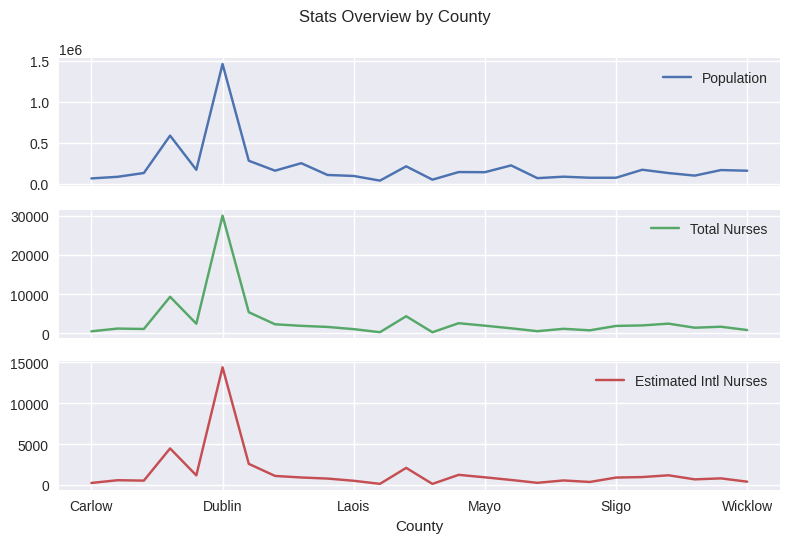

In [ ]:
df = master_df.set_index('County')
# Selecting relevant columns that make sense to plot together
selected_columns = ['Population', 'Total Nurses', 'Estimated Intl Nurses']

df[selected_columns].plot(subplots=True, title = 'Stats Overview by County')
plt.tight_layout()
plt.show()


In [ ]:
bar1 = px.bar(df.reset_index().sort_values('Nurses per 10k', ascending = False),
    x = 'Nurses per 10k',
    y = 'County',
    orientation = 'h',
    title = 'Nurses per 10k Population by County',
    height = 800) # Increased height to display all 26 counties

bar1.update_xaxes(title_text = 'Nurses per 10k')
bar1.update_yaxes(title_text = 'County')

In [ ]:
bar2 = px.bar(df.reset_index().sort_values('Beds per 10k', ascending = False),
    x = 'Beds per 10k',
    y = 'County',
    orientation = 'h',
    title = 'Beds per 10k Population by County',
    height = 800) # Increased height to display all 26 counties
bar2.update_xaxes(title_text = 'Beds per 10k')
bar2.update_yaxes(title_text = 'County')

In [ ]:
bar3 = px.bar(df.reset_index().sort_values('Hospitals per 10k', ascending = False),
    x = 'Hospitals per 10k',
    y = 'County',
    orientation = 'h',
    title = 'Hospitals per 10k Population by County',
    height = 800) # Increased height to display all 26 counties
bar3.update_xaxes(title_text = 'Hospitals per 10k')
bar3.update_yaxes(title_text = 'County')

In [ ]:
fig4 = px.scatter(df.reset_index(), x = 'Estimated Intl Nurses', y = 'Rent % Salary', hover_name = 'County',
title = 'Estimated International Nurses vs. Rent Affordability by County',
labels = {'Estimated Intl Nurses': 'Estimated International Nurses', 'Rent % Salary': 'Rent as % of Nurse Salary'},
height = 600)
fig4.update_layout(title_x=0.5) # Centering the title

# Adding a horizontal line at 30% rent burden
fig4.add_hline(y=0.30, line_dash="dash", line_color="red", annotation_text="30% Rent Burden", annotation_position="bottom right")

fig4.show()

In [ ]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES"
counties = gpd.read_file('Census2011Counties.shp')
counties

,NUTS1,NUTS1NAME,NUTS2,NUTS2NAME,NUTS3,NUTS3NAME,COUNTY,COUNTYNAME,Male2011,Female2011,Total2011,PPOcc2011,Unocc2011,HS2011,Vacant2011,PCVac20111,TOTAL_AREA,LAND_AREA,CREATEDATE,geometry
0,IE0,Ireland,IE01,"Border,Midland and Western",IE011,Border,33,Donegal County,80523.0,80614.0,161137.0,58300.0,25618.0,83918.0,23996.0,28.6,4862.720653,4764.357841,27-03-2012,"MULTIPOLYGON (((146275.913 379874.953, 146256...."
1,IE0,Ireland,IE01,"Border,Midland and Western",IE011,Border,34,Monaghan County,30441.0,30042.0,60483.0,21241.0,3815.0,25056.0,3398.0,13.6,1294.718927,1273.442423,27-03-2012,"POLYGON ((263301.014 352698.191, 263539.522 35..."
2,IE0,Ireland,IE02,Southern and Eastern,IE024,South-East (IE),01,Carlow County,27431.0,27181.0,54612.0,19507.0,3658.0,23165.0,3202.0,13.8,896.699022,894.772587,27-03-2012,"POLYGON ((286831.002 185881.97, 287438.116 185..."
3,IE0,Ireland,IE02,Southern and Eastern,IE021,Dublin,35,Dublin County,257303.0,270309.0,527612.0,209920.0,31758.0,241678.0,24638.0,10.2,117.667128,116.581205,27-03-2012,"MULTIPOLYGON (((327683.704 226508.087, 327735...."
4,IE0,Ireland,IE02,Southern and Eastern,IE022,Mid-East,06,Kildare County,104658.0,105654.0,210312.0,70777.0,8017.0,78794.0,6311.0,8.0,1694.819228,1693.257035,27-03-2012,"POLYGON ((269728.403 244270.048, 269840.826 24..."
5,IE0,Ireland,IE02,Southern and Eastern,IE024,South-East (IE),07,Kilkenny County,47788.0,47631.0,95419.0,33681.0,5324.0,39005.0,4624.0,11.9,2072.005089,2061.029158,27-03-2012,"POLYGON ((254625.885 182835.159, 254966.29 182..."
6,IE0,Ireland,IE01,"Border,Midland and Western",IE012,Midland,08,Laois County,40587.0,39972.0,80559.0,27991.0,4673.0,32664.0,4087.0,12.5,1719.875609,1719.161816,27-03-2012,"POLYGON ((241810.798 217894.955, 241895.467 21..."
7,IE0,Ireland,IE01,"Border,Midland and Western",IE012,Midland,09,Longford County,19649.0,19351.0,39000.0,14460.0,4363.0,18823.0,4075.0,21.6,1091.550910,1039.526935,27-03-2012,"POLYGON ((223420.563 298777.86, 223514.24 2987..."
8,IE0,Ireland,IE01,"Border,Midland and Western",IE011,Border,10,Louth County,60763.0,62134.0,122897.0,44060.0,7126.0,51186.0,6232.0,12.2,827.012162,823.582520,27-03-2012,"POLYGON ((306570.43 309491.953, 306521.673 309..."
9,IE0,Ireland,IE02,Southern and Eastern,IE022,Mid-East,11,Meath County,91910.0,92225.0,184135.0,62085.0,7612.0,69697.0,6173.0,8.9,2343.056858,2331.927433,27-03-2012,"POLYGON ((283537.67 297124.464, 283611.275 296..."


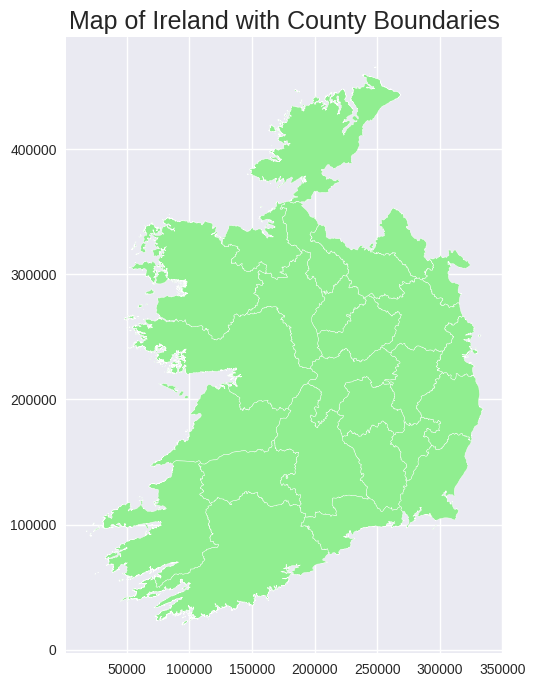

In [ ]:
# Uploading my shape file of Ireland with county boundaries
fig5, ax = plt.subplots(figsize = (10,8))
counties.plot(ax = ax, edgecolor = 'white', color = 'lightgreen')
ax.set_title('Map of Ireland with County Boundaries', fontsize = 18)
plt.show()

In [ ]:
hospital_locations = gpd.read_file('hospital_locations.shp')
hospital_locations.head(5)

,name,Total Beds,POINT_X,POINT_Y,County,geometry
0,Saint Colman's Hospital,92,-6.239776,52.933818,Wicklow,POINT (-6.23978 52.93382)
1,Saint Mary's Hospital - Castleblayney,70,-6.744803,54.120058,Monaghan,POINT (-6.7448 54.12006)
2,Our Lady of Lourdes Hospital Drogheda,340,-6.354947,53.722735,Louth,POINT (-6.35495 53.72274)
3,Drogheda,345,-6.341016,53.711363,Louth,POINT (-6.34102 53.71136)
4,Blackrock Clinic,232,-6.188172,53.303468,Dublin,POINT (-6.18817 53.30347)


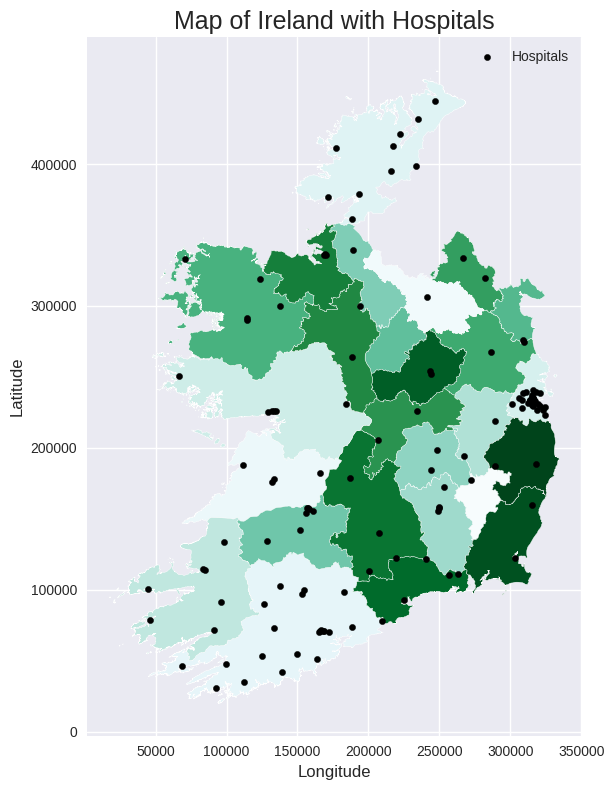

In [ ]:
fig6, ax = plt.subplots(figsize = (10,8))

counties.plot(ax = ax, edgecolor = 'white', column = 'COUNTYNAME', cmap = 'BuGn')
# Plotting the county boundaries

hospital_locations.plot(ax = ax, color = 'black', markersize = 20, label = 'Hospitals')
# Plotting the hospital locations on the same axes

# Add a title and legend
ax.set_title('Map of Ireland with Hospitals', fontsize=18)
ax.set_xlabel('Longitude', fontsize = 12)
ax.set_ylabel('Latitude', fontsize = 12)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
hospital_locations = gpd.read_file('hospital_locations.shp')
# Code taken from https://plotly.com/python/tile-scatter-maps/
fig7 = px.scatter_map(hospital_locations,
                        lat=hospital_locations.geometry.y,
                        lon=hospital_locations.geometry.x,
                        hover_name='name',
                        # Added hover_data to show more information
                        hover_data=['County', 'Total Beds'],
                        zoom=1)
fig7.show()